In [19]:
import pandas as pd



## Transformacion

In [20]:
icaeh_2022=pd.read_csv("ICAE_municipal/ICAEH_2022.csv")
icaeh_2023=pd.read_csv("ICAE_municipal/ICAEH_2023_50.csv")
icaeh_2024=pd.read_csv("ICAE_municipal/ICAEH_2024_50.csv")




In [21]:
def flatten_iae(df):
    df['IAE'] = df['IAE'].str.replace('%', '', regex=False).astype(float) / 100


flatten_iae(icaeh_2022)
flatten_iae(icaeh_2023)
flatten_iae(icaeh_2024)



In [22]:
icaeh_2022['COBERTURA'] =(pd.to_numeric(icaeh_2022['COBERTURA'].str.replace(',', '', regex=False), errors='coerce')
                        .fillna(0))

In [ ]:
# Solo si estás SEGURO de que todos tienen 5 columnas
new_column_names = ["DEPARTAMENTO", "MUNICIPIO", "TOTAL_DE_VIVIENDAS", 
                    "VIVIENDAS_CON_ACCESO_A_ELECTRICIDAD", "IAE"]


icaeh_2024[['Departamentos', 'Municipios']] = icaeh_2024[['Municipios', 'Departamentos']].values


icaeh_2022 = icaeh_2022.drop(columns=['ICE'], errors='ignore')

icaeh_2022.columns = new_column_names
icaeh_2023.columns = new_column_names
icaeh_2024.columns = new_column_names
icaeh_2022["YEAR"]=2022
icaeh_2023["YEAR"]=2023
icaeh_2024["YEAR"]=2024
# Unir
df_completo = pd.concat([icaeh_2022, icaeh_2023, icaeh_2024], ignore_index=True)
df_completo["DEPARTAMENTO"] = df_completo["DEPARTAMENTO"].str.title()

In [24]:
df_completo.head(30)


,DEPARTAMENTO,MUNICIPIO,TOTAL_DE_VIVIENDAS,VIVIENDAS_CON_ACCESO_A_ELECTRICIDAD,IAE,YEAR
0,Atlántida,La Ceiba,"58,999",57918.0,0.9831,2022
1,Atlántida,El Porvenir,"6,894",6657.0,0.9692,2022
2,Atlántida,Esparta,"6,580",4574.0,0.7047,2022
3,Atlántida,Jutiapa,"9,011",7340.0,0.8414,2022
4,Atlántida,La Masica,"12,779",7763.0,0.6231,2022
5,Atlántida,San Francisco del Valle,"4,422",3910.0,0.8924,2022
6,Atlántida,Tela,"36,646",26958.0,0.7428,2022
7,Atlántida,Arizona,"9,002",6590.0,0.7352,2022
8,Colón,Trujillo,"16,804",16120.0,0.9642,2022
9,Colón,Balfate,"2,275",2253.0,1.1130,2022


Total de registros: 338
Municipios con IAE < 50%: 50


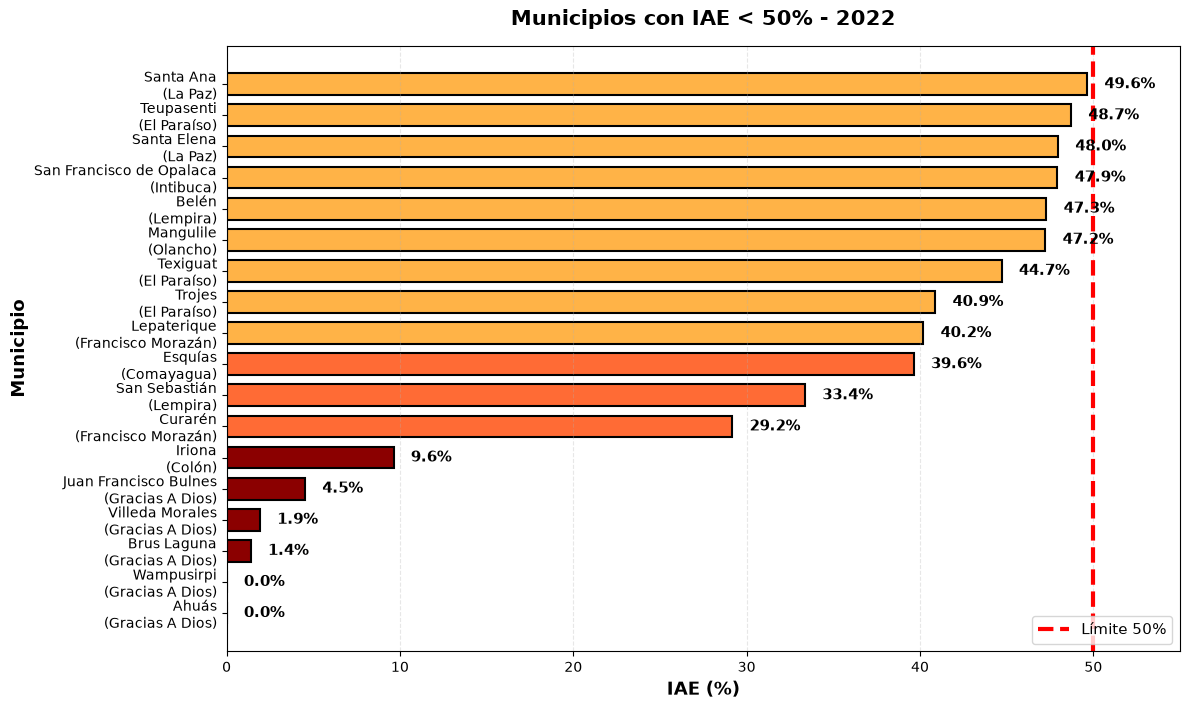

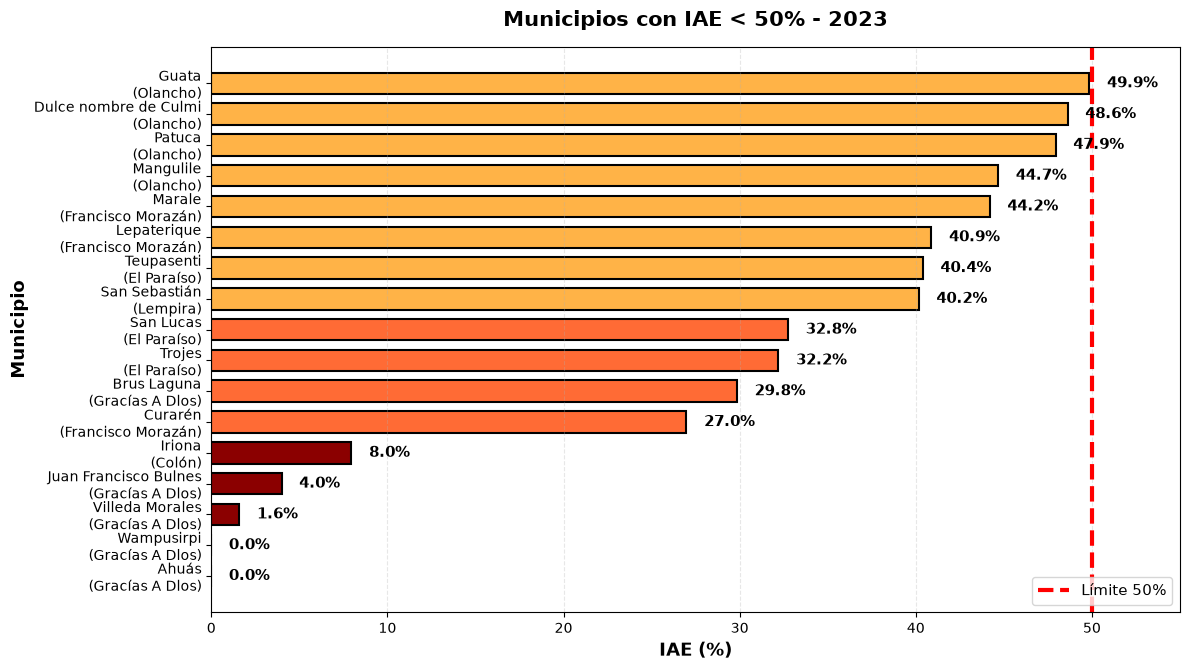

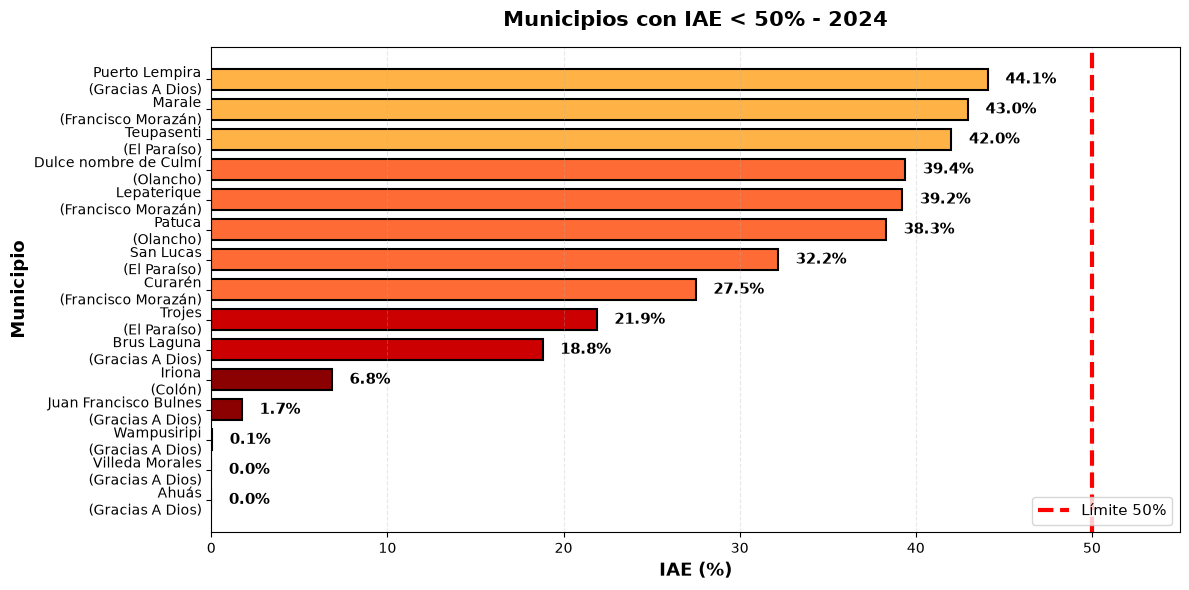

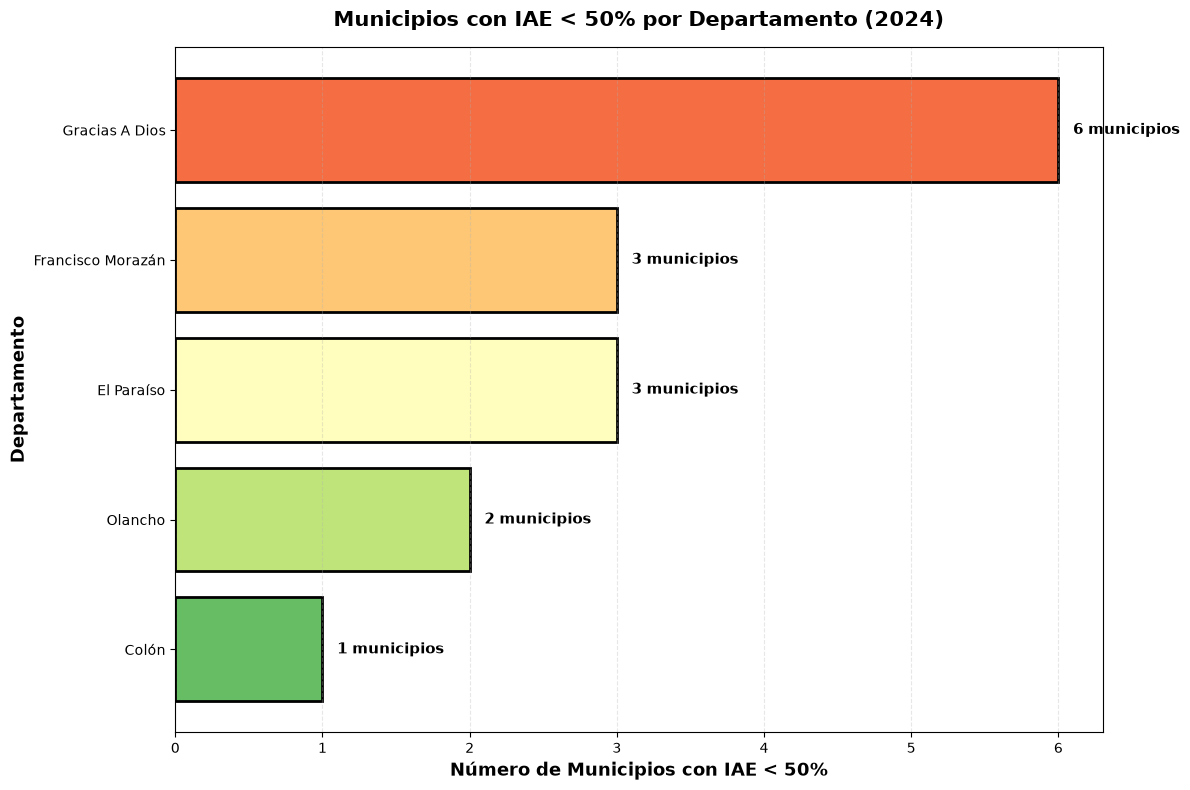

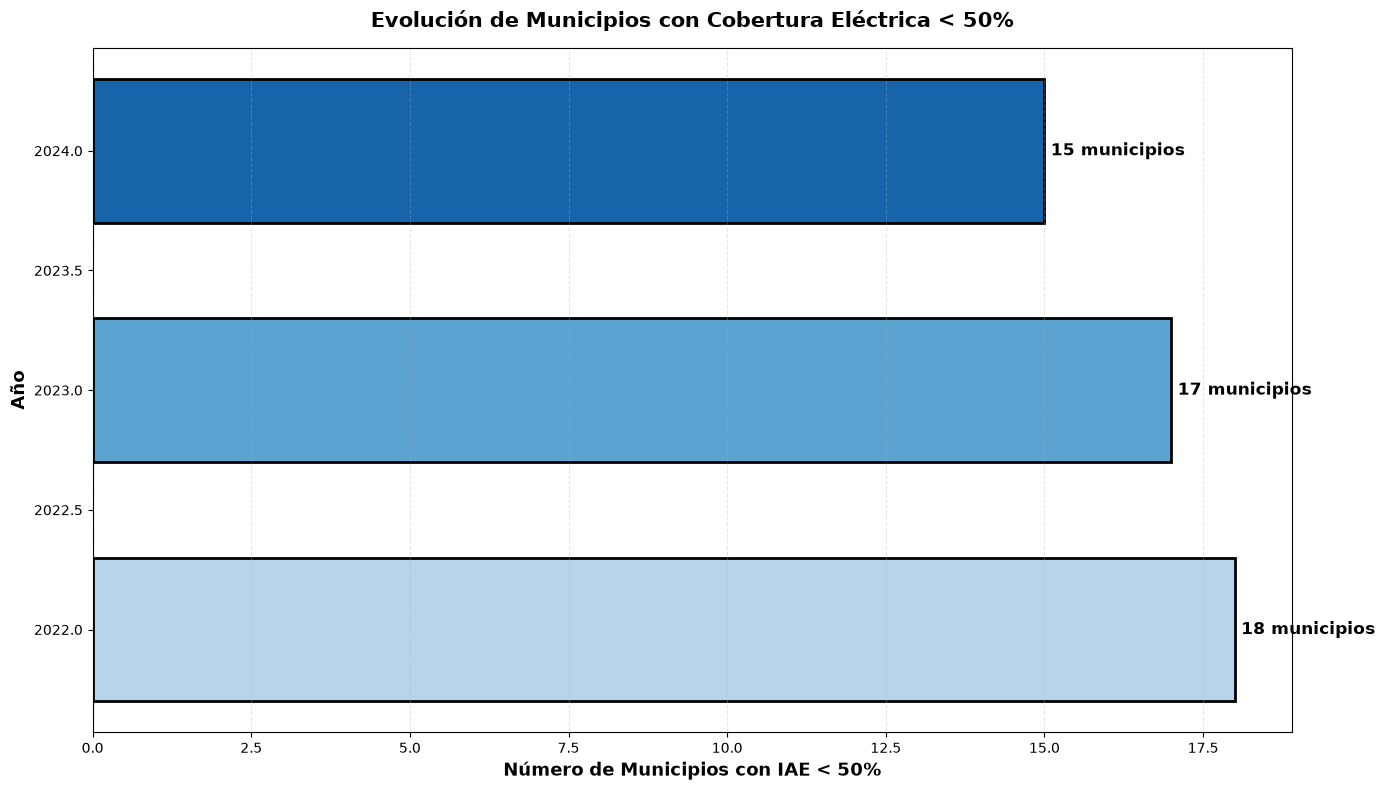

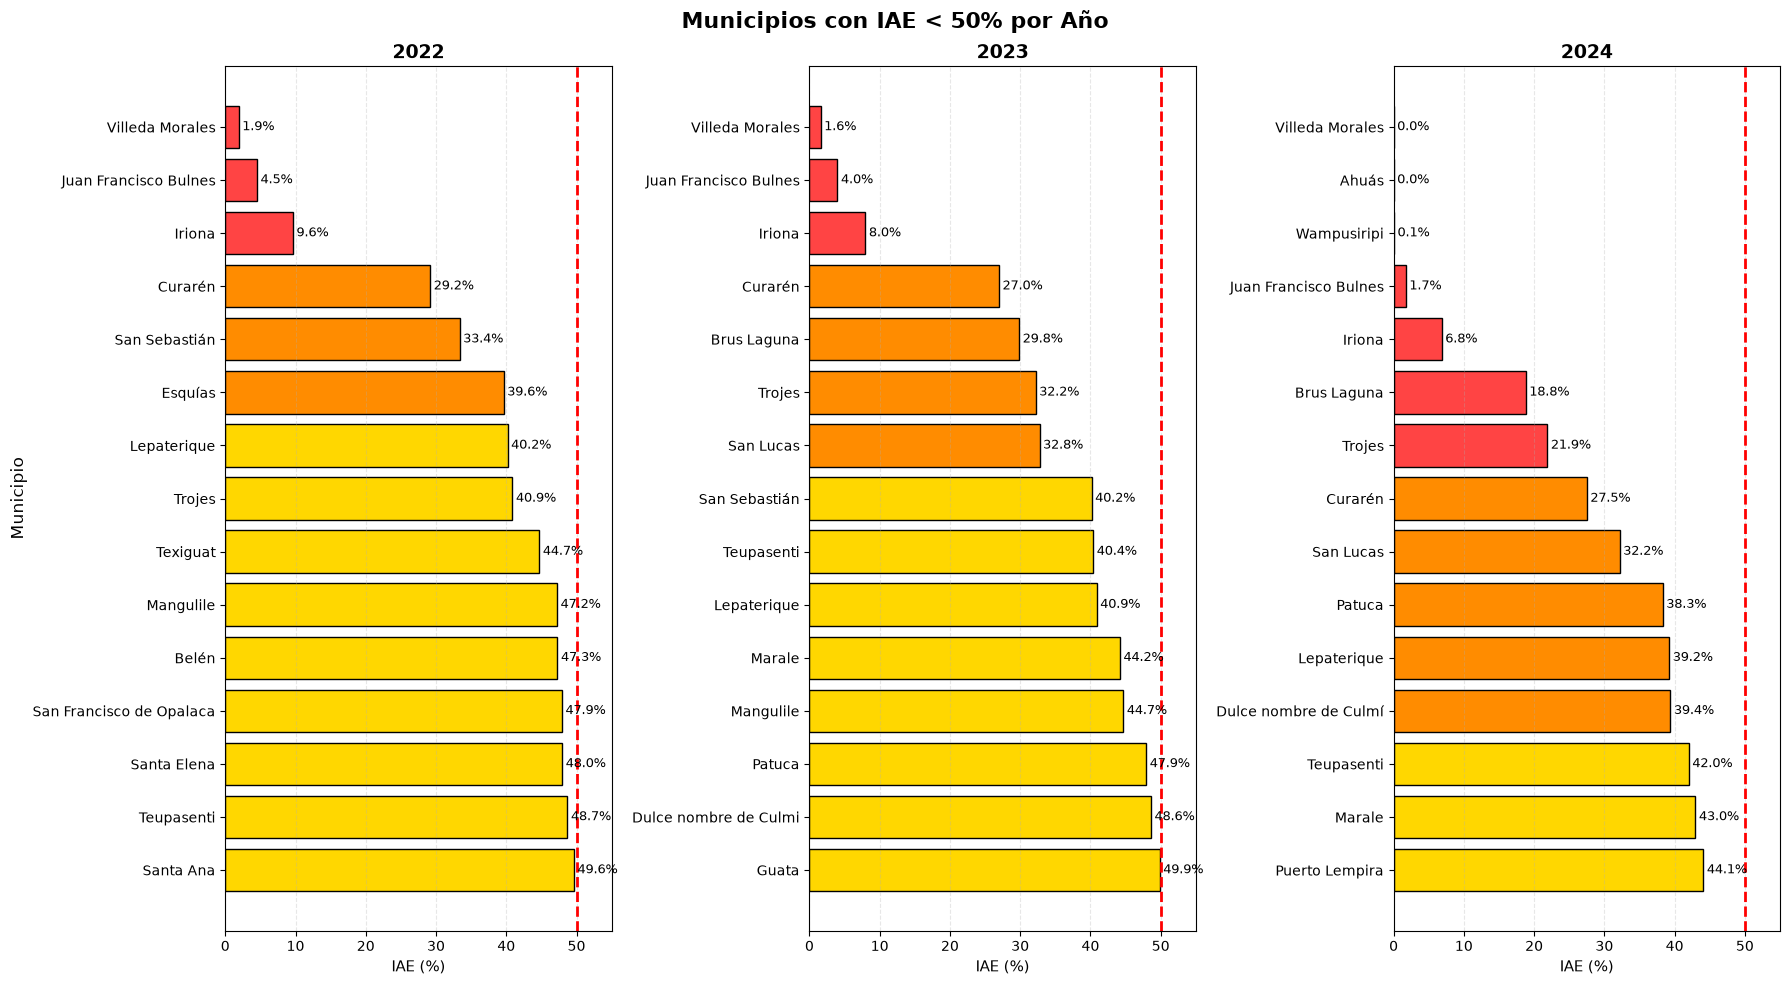

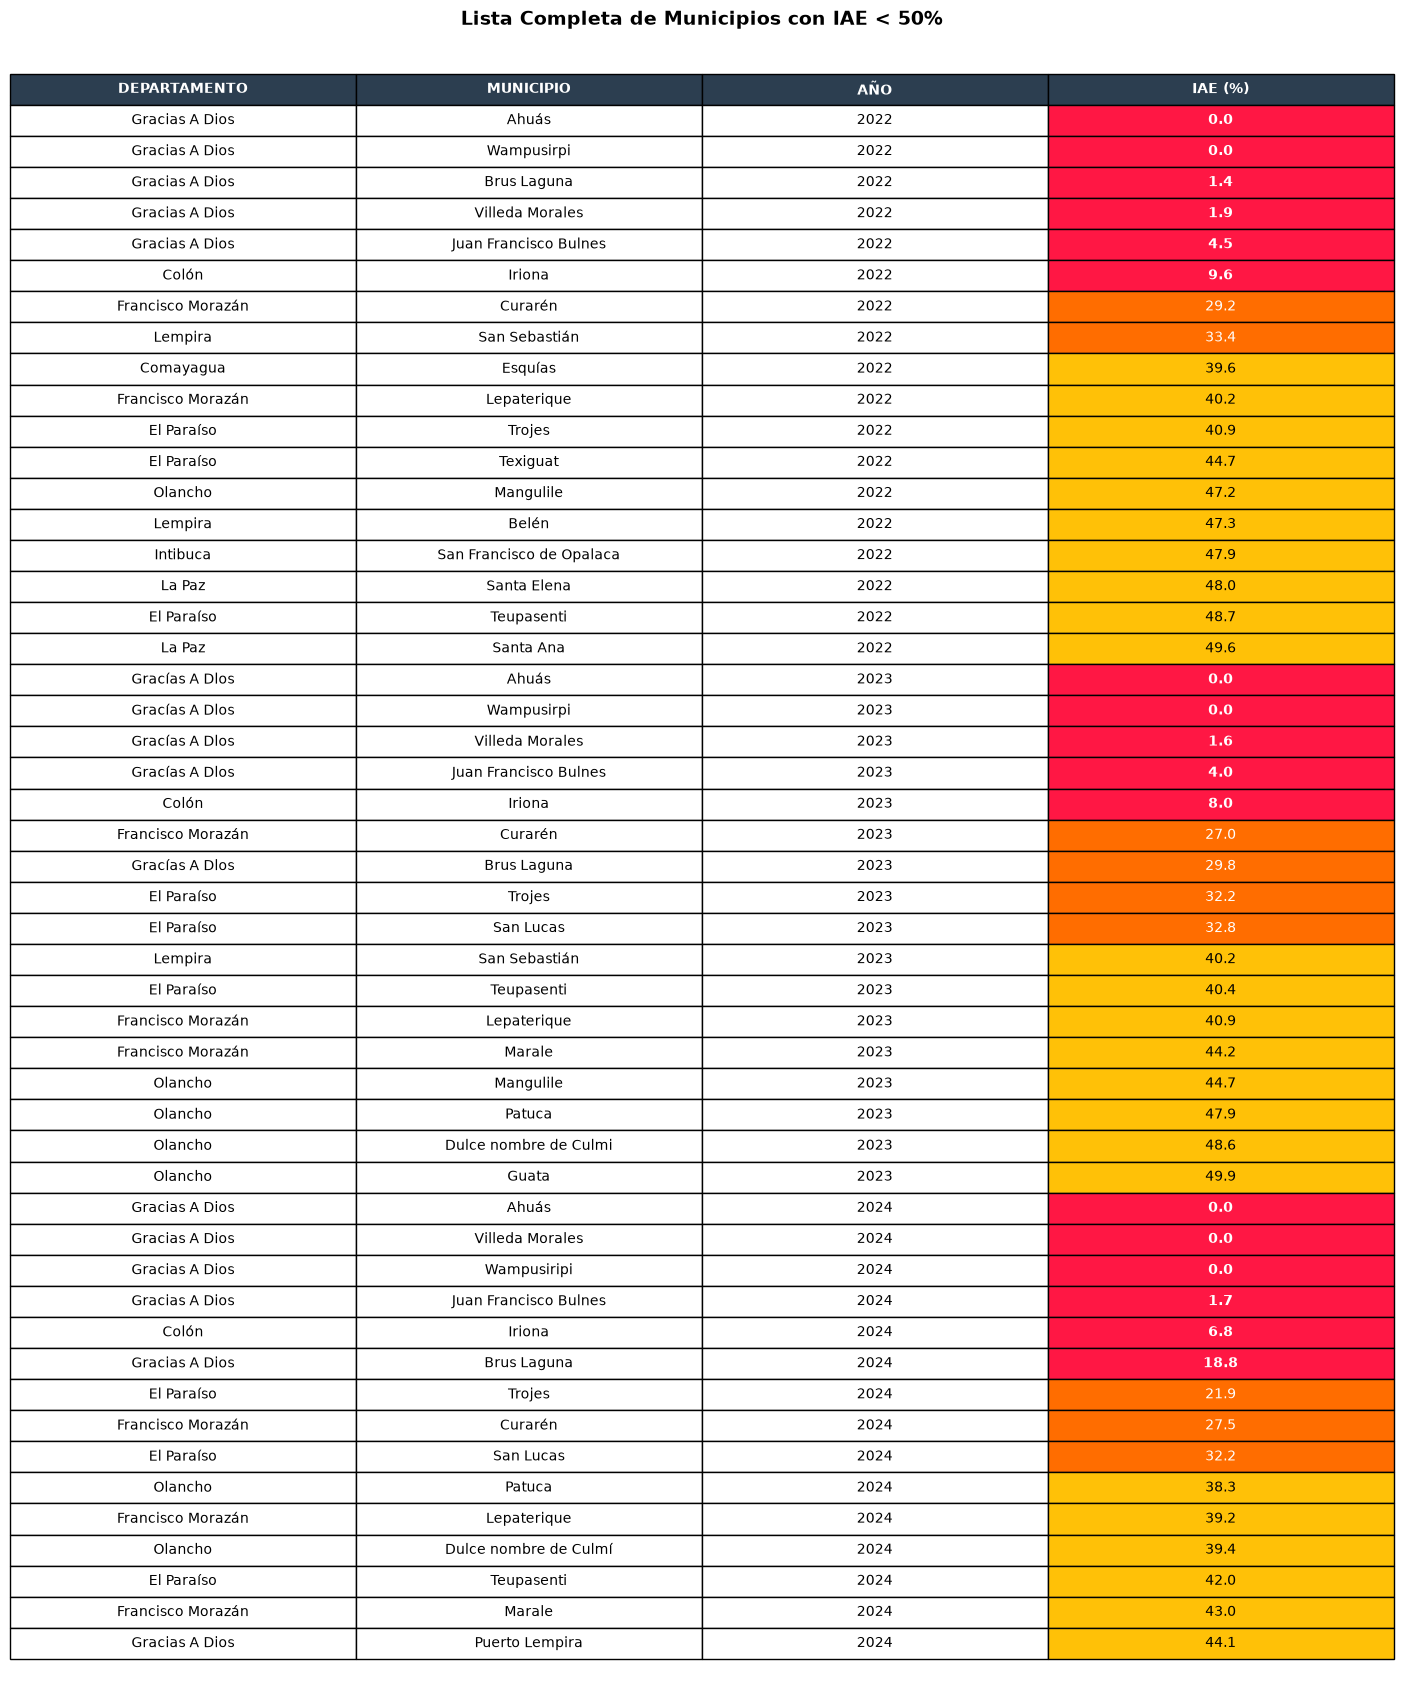


✅ Datos exportados a 'municipios_bajo_50_iae.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualizar_municipios_bajo_50_horizontal(df):
    """
    Visualiza los municipios con IAE < 50% con gráficos horizontales
    
    Parámetros:
    df: DataFrame con columnas 'DEPARTAMENTO', 'MUNICIPIO', 'IAE', 'YEAR'
    """
    
    # ============================================
    # 1. PREPARAR DATOS
    # ============================================
    
    # Asegurar que IAE sea numérico
    if df['IAE'].dtype == 'object':
        df['IAE'] = df['IAE'].str.replace('%', '').astype(float)
        df['IAE'] = df['IAE'] / 100
    
    # Filtrar municipios con IAE < 0.50 (50%)
    df_bajo_50 = df[df['IAE'] < 0.50].copy()
    
    print(f"Total de registros: {len(df)}")
    print(f"Municipios con IAE < 50%: {len(df_bajo_50)}")
    
    if df_bajo_50.empty:
        print("\n✅ ¡Excelente! Todos los municipios tienen IAE >= 50%")
        return None
    
    # ============================================
    # 2. GRÁFICO 1: BARRAS HORIZONTALES POR AÑO
    # ============================================
    
    years = sorted(df_bajo_50['YEAR'].unique())
    
    for year in years:
        data_year = df_bajo_50[df_bajo_50['YEAR'] == year].sort_values('IAE', ascending=True)
        
        if data_year.empty:
            print(f"\n✅ {year}: No hay municipios bajo 50%")
            continue
        
        # Crear figura con tamaño dinámico
        fig, ax = plt.subplots(figsize=(12, max(5, len(data_year) * 0.4)))
        
        # Preparar datos
        etiquetas = [f"{row['MUNICIPIO']}\n({row['DEPARTAMENTO']})" for _, row in data_year.iterrows()]
        valores = data_year['IAE'].values * 100  # Convertir a porcentaje
        
        # Colores según rango
        colors = []
        for v in valores:
            if v < 10:
                colors.append('#8B0000')  # Rojo oscuro
            elif v < 25:
                colors.append('#CC0000')  # Rojo
            elif v < 40:
                colors.append('#FF6B35')  # Naranja
            else:
                colors.append('#FFB347')  # Naranja claro
        
        # Crear barras horizontales
        bars = ax.barh(etiquetas, valores, color=colors, edgecolor='black', linewidth=1.5, height=0.7)
        
        # Línea vertical del 50%
        ax.axvline(x=50, color='red', linestyle='--', linewidth=3, label='Límite 50%')
        
        # Agregar valores en las barras
        for i, (bar, val) in enumerate(zip(bars, valores)):
            ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
        
        # Personalizar gráfico
        ax.set_xlabel('IAE (%)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Municipio', fontsize=13, fontweight='bold')
        ax.set_title(f'Municipios con IAE < 50% - {year}', fontsize=15, fontweight='bold', pad=15)
        ax.legend(loc='lower right', fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--', axis='x')
        ax.set_xlim(0, 55)
        
        # Ajustar diseño
        plt.tight_layout()
        plt.show()
    
    # ============================================
    # 3. GRÁFICO 2: COMPARATIVA POR DEPARTAMENTO
    # ============================================
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Usar el último año disponible
    ultimo_año = max(df_bajo_50['YEAR'])
    data_ultimo = df_bajo_50[df_bajo_50['YEAR'] == ultimo_año]
    
    if not data_ultimo.empty:
        conteo_dep = data_ultimo.groupby('DEPARTAMENTO').size().sort_values(ascending=True)
        
        colors_dep = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(conteo_dep)))
        
        bars = ax.barh(conteo_dep.index, conteo_dep.values, color=colors_dep, edgecolor='black', linewidth=2)
        
        # Agregar números
        for bar, count in zip(bars, conteo_dep.values):
            ax.text(count + 0.1, bar.get_y() + bar.get_height()/2, 
                   f'{count} municipios', va='center', fontsize=11, fontweight='bold')
        
        ax.set_xlabel('Número de Municipios con IAE < 50%', fontsize=13, fontweight='bold')
        ax.set_ylabel('Departamento', fontsize=13, fontweight='bold')
        ax.set_title(f'Municipios con IAE < 50% por Departamento ({ultimo_año})', 
                     fontsize=15, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='x')
        
        plt.tight_layout()
        plt.show()
    
    # ============================================
    # 4. GRÁFICO 3: EVOLUCIÓN TEMPORAL
    # ============================================
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Contar municipios bajo 50% por año
    conteo_por_año = df_bajo_50.groupby('YEAR')['MUNICIPIO'].nunique()
    
    # Crear barras horizontales
    bars = ax.barh(conteo_por_año.index, conteo_por_año.values, 
                   color=plt.cm.Blues(np.linspace(0.3, 0.8, len(conteo_por_año))),
                   edgecolor='black', linewidth=2, height=0.6)
    
    # Agregar números
    for bar, count in zip(bars, conteo_por_año.values):
        ax.text(count + 0.1, bar.get_y() + bar.get_height()/2, 
               f'{count} municipios', va='center', fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Número de Municipios con IAE < 50%', fontsize=13, fontweight='bold')
    ax.set_ylabel('Año', fontsize=13, fontweight='bold')
    ax.set_title('Evolución de Municipios con Cobertura Eléctrica < 50%', 
                 fontsize=15, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 5. GRÁFICO 4: TODOS LOS AÑOS JUNTOS (FACETAS)
    # ============================================
    
    if len(years) >= 2:
        fig, axes = plt.subplots(1, len(years), figsize=(18, 10))
        
        if len(years) == 1:
            axes = [axes]
        
        for idx, year in enumerate(years):
            data_year = df_bajo_50[df_bajo_50['YEAR'] == year].sort_values('IAE', ascending=False)
            
            if data_year.empty:
                axes[idx].text(0.5, 0.5, f'{year}\nSin municipios bajo 50%', 
                              ha='center', va='center', fontsize=14, transform=axes[idx].transAxes)
                axes[idx].set_title(f'{year}', fontsize=14, fontweight='bold')
                continue
            
            # Tomar top 15 o todos
            data_plot = data_year.head(15)
            etiquetas = [f"{row['MUNICIPIO']}" for _, row in data_plot.iterrows()]
            valores = data_plot['IAE'].values * 100
            
            colors = ['#FF4444' if v < 25 else '#FF8C00' if v < 40 else '#FFD700' for v in valores]
            
            bars = axes[idx].barh(etiquetas, valores, color=colors, edgecolor='black', linewidth=1)
            
            # Agregar valores
            for bar, val in zip(bars, valores):
                axes[idx].text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                              f'{val:.1f}%', va='center', fontsize=9)
            
            axes[idx].axvline(x=50, color='red', linestyle='--', linewidth=2)
            axes[idx].set_xlim(0, 55)
            axes[idx].set_xlabel('IAE (%)', fontsize=11)
            axes[idx].set_title(f'{year}', fontsize=14, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, linestyle='--', axis='x')
            
            if idx == 0:
                axes[idx].set_ylabel('Municipio', fontsize=12)
        
        plt.suptitle('Municipios con IAE < 50% por Año', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # ============================================
    # 6. TABLA RESUMEN (Opcional)
    # ============================================
    
    # Tabla con todos los municipios bajo 50%
    fig, ax = plt.subplots(figsize=(14, max(4, len(df_bajo_50) * 0.3 + 2)))
    ax.axis('tight')
    ax.axis('off')
    
    tabla_data = df_bajo_50[['DEPARTAMENTO', 'MUNICIPIO', 'YEAR', 'IAE']].copy()
    tabla_data['IAE'] = (tabla_data['IAE'] * 100).round(1)
    tabla_data = tabla_data.sort_values(['YEAR', 'IAE'], ascending=[True, True])
    
    # Colorear según año
    colores_fila = []
    for year in tabla_data['YEAR']:
        if year == 2022:
            colores_fila.append('#E8F4FD')
        elif year == 2023:
            colores_fila.append('#FFF9E6')
        else:
            colores_fila.append('#E8F5E9')
    
    # Crear tabla
    table = ax.table(cellText=tabla_data.values,
                     colLabels=['DEPARTAMENTO', 'MUNICIPIO', 'AÑO', 'IAE (%)'],
                     cellLoc='center',
                     loc='center',
                     colColours=['#2C3E50']*4)
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Colorear celdas
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # Encabezados
            cell.set_text_props(color='white', fontweight='bold')
        elif j == 3:  # Columna IAE
            try:
                valor = float(tabla_data.iloc[i-1, j])
                if valor < 20:
                    cell.set_facecolor('#FF1744')
                    cell.set_text_props(color='white', fontweight='bold')
                elif valor < 35:
                    cell.set_facecolor('#FF6D00')
                    cell.set_text_props(color='white')
                elif valor < 50:
                    cell.set_facecolor('#FFC107')
            except:
                pass
    
    plt.title('Lista Completa de Municipios con IAE < 50%', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 7. EXPORTAR RESULTADOS
    # ============================================
    
    df_bajo_50.to_csv('municipios_bajo_50_iae.csv', index=False)
    print(f"\n✅ Datos exportados a 'municipios_bajo_50_iae.csv'")
    
    return df_bajo_50


# ============================================
# EJEMPLO DE USO
# ============================================

if __name__ == "__main__":
    # Cargar tus datos reales
  
    
    # Ejecutar visualización
    df_bajo_50 = visualizar_municipios_bajo_50_horizontal(df_completo)

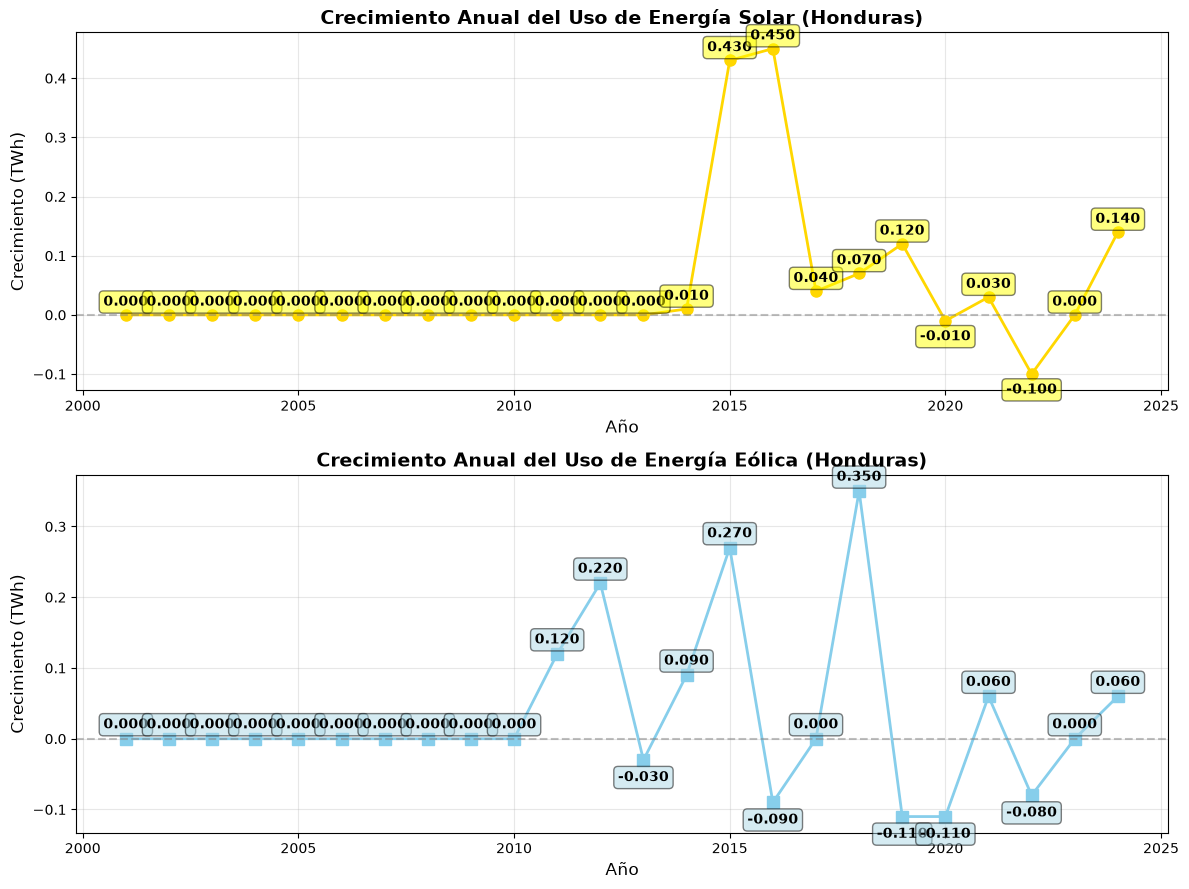

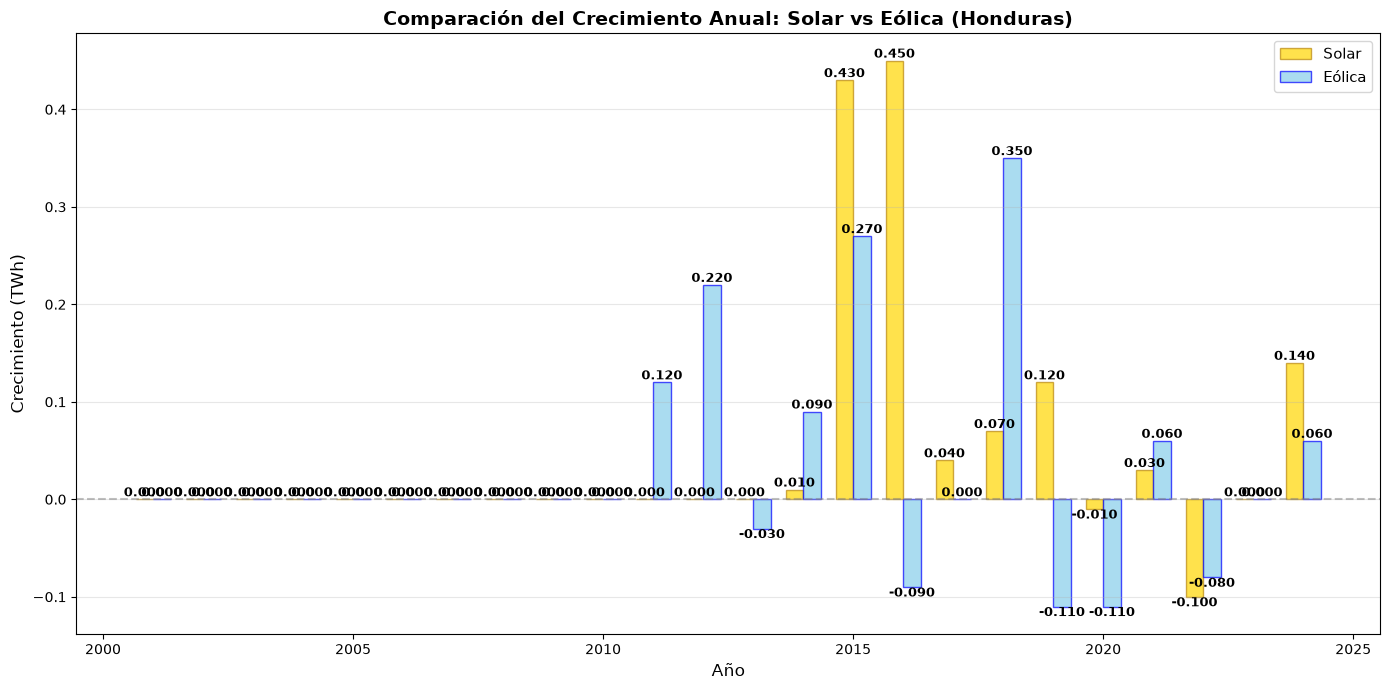


DATOS DE CRECIMIENTO ANUAL DE ENERGÍA EN HONDURAS
    Year  Solar  Solar_growth  Wind  Wind_growth
0   2000   0.00           NaN  0.00          NaN
1   2001   0.00          0.00  0.00         0.00
2   2002   0.00          0.00  0.00         0.00
3   2003   0.00          0.00  0.00         0.00
4   2004   0.00          0.00  0.00         0.00
5   2005   0.00          0.00  0.00         0.00
6   2006   0.00          0.00  0.00         0.00
7   2007   0.00          0.00  0.00         0.00
8   2008   0.00          0.00  0.00         0.00
9   2009   0.00          0.00  0.00         0.00
10  2010   0.00          0.00  0.00         0.00
11  2011   0.00          0.00  0.12         0.12
12  2012   0.00          0.00  0.34         0.22
13  2013   0.00          0.00  0.31        -0.03
14  2014   0.01          0.01  0.40         0.09
15  2015   0.44          0.43  0.67         0.27
16  2016   0.89          0.45  0.58        -0.09
17  2017   0.93          0.04  0.58         0.00
18  2018   1.00   

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer el archivo CSV
df = pd.read_csv('data/electricity-prod-source-stacked.csv')



# Filtrar solo los datos de Honduras (por si hay otros países)
df_honduras = df[df['Entity'] == 'Honduras'].copy()

# Ordenar por año para asegurar la secuencia correcta
df_honduras = df_honduras.sort_values('Year')

# Calcular el crecimiento anual (cambio absoluto) para Solar y Wind
df_honduras['Solar_growth'] = df_honduras['Solar'].diff()
df_honduras['Wind_growth'] = df_honduras['Wind'].diff()

# Crear una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# Gráfico 1: Crecimiento de Energía Solar
ax1.plot(df_honduras['Year'], df_honduras['Solar_growth'], 
         marker='o', linestyle='-', color='gold', linewidth=2, markersize=8)
ax1.set_title('Crecimiento Anual del Uso de Energía Solar (Honduras)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Crecimiento (TWh)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Agregar etiquetas con los valores de crecimiento para Solar
for i, (year, growth) in enumerate(zip(df_honduras['Year'], df_honduras['Solar_growth'])):
    if not pd.isna(growth):  # Ignorar el primer año (NaN)
        # Determinar la posición vertical de la etiqueta
        y_offset = 0.01 if growth >= 0 else -0.015
        ax1.text(year, growth + y_offset, f'{growth:.3f}', 
                ha='center', va='bottom' if growth >= 0 else 'top',
                fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# Gráfico 2: Crecimiento de Energía Eólica
ax2.plot(df_honduras['Year'], df_honduras['Wind_growth'], 
         marker='s', linestyle='-', color='skyblue', linewidth=2, markersize=8)
ax2.set_title('Crecimiento Anual del Uso de Energía Eólica (Honduras)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Año', fontsize=12)
ax2.set_ylabel('Crecimiento (TWh)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Agregar etiquetas con los valores de crecimiento para Wind
for i, (year, growth) in enumerate(zip(df_honduras['Year'], df_honduras['Wind_growth'])):
    if not pd.isna(growth):  # Ignorar el primer año (NaN)
        y_offset = 0.01 if growth >= 0 else -0.015
        ax2.text(year, growth + y_offset, f'{growth:.3f}', 
                ha='center', va='bottom' if growth >= 0 else 'top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))

# Ajustar espaciado y mostrar
plt.tight_layout()
plt.show()

# Gráfico de barras comparativo con etiquetas
fig2, ax = plt.subplots(figsize=(14, 7))

# Configurar ancho de barras
width = 0.35
years = df_honduras['Year'][1:]  # Desde el segundo año (no hay crecimiento en el primero)

# Crear barras para el crecimiento
bars1 = ax.bar(years - width/2, df_honduras['Solar_growth'][1:], 
               width, label='Solar', color='gold', alpha=0.7, edgecolor='darkgoldenrod')
bars2 = ax.bar(years + width/2, df_honduras['Wind_growth'][1:], 
               width, label='Eólica', color='skyblue', alpha=0.7, edgecolor='blue')

ax.set_title('Comparación del Crecimiento Anual: Solar vs Eólica (Honduras)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Crecimiento (TWh)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Agregar etiquetas de valores en las barras de Solar
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=9, fontweight='bold')

# Agregar etiquetas de valores en las barras de Eólica
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar también los datos en consola para referencia
print("\n" + "="*70)
print("DATOS DE CRECIMIENTO ANUAL DE ENERGÍA EN HONDURAS")
print("="*70)
print(df_honduras[['Year', 'Solar', 'Solar_growth', 'Wind', 'Wind_growth']].to_string())
print("="*70)

# Mostrar estadísticas resumidas
print("\n📊 ESTADÍSTICAS RESUMEN:")
print(f"Crecimiento promedio Solar: {df_honduras['Solar_growth'].mean():.4f} TWh/año")
print(f"Crecimiento promedio Eólica: {df_honduras['Wind_growth'].mean():.4f} TWh/año")
print(f"Crecimiento total Solar: {df_honduras['Solar_growth'].sum():.4f} TWh")
print(f"Crecimiento total Eólica: {df_honduras['Wind_growth'].sum():.4f} TWh")